**Block 1: Setup & Environment Configuration**

In [ ]:
# Install required libraries
!pip install python-docx scikit-learn seaborn matplotlib pandas numpy -q
!apt-get update -qq && apt-get install -y libreoffice -qq

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

import docx
from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from google.colab import files

sns.set_theme(style="whitegrid")
print("Environment configured successfully.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Environment configured successfully.


**Block 2: End-to-End Synthesis Pipeline & Visual Generation**

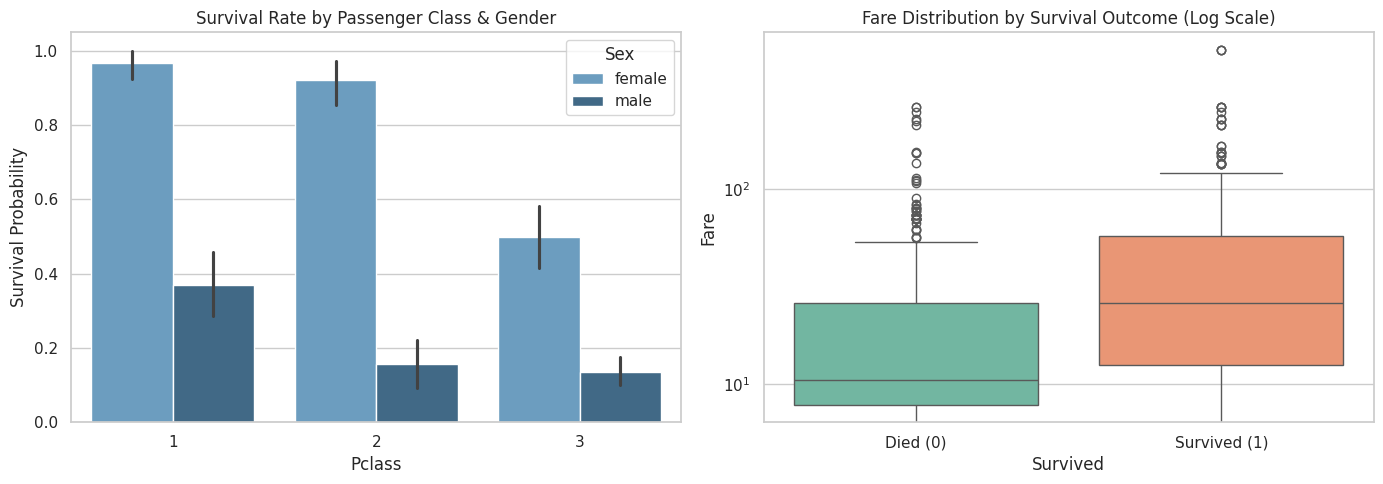

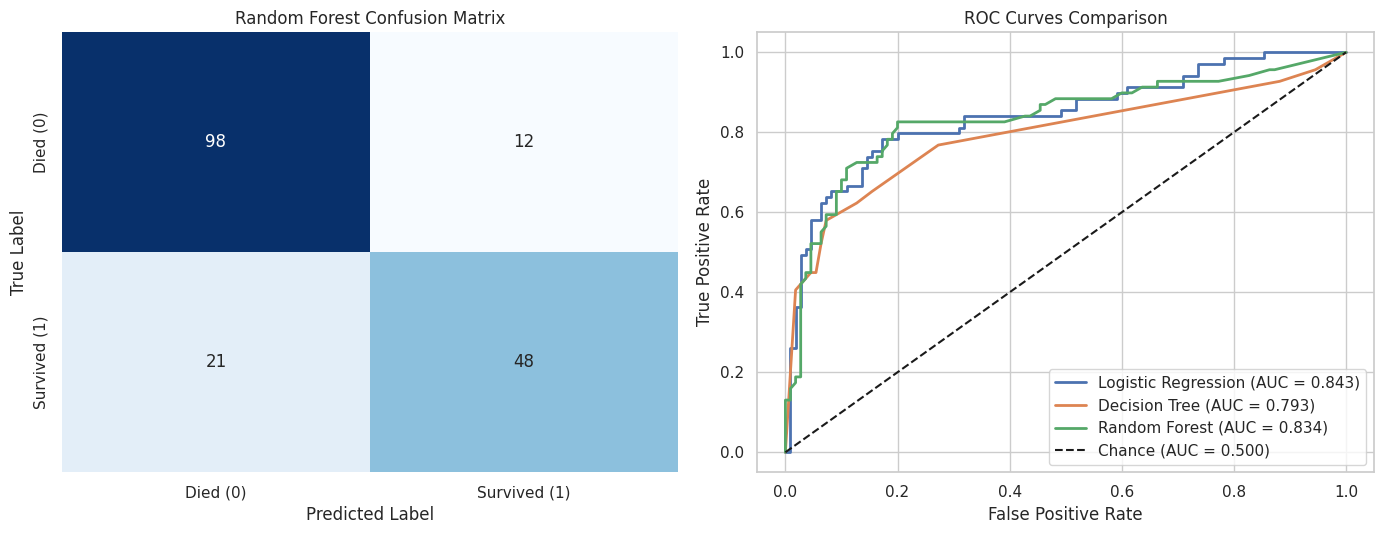

In [ ]:
# Load dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Define feature subsets
features_num = ['Age', 'Fare', 'SibSp', 'Parch']
features_cat = ['Pclass', 'Sex', 'Embarked']
target = 'Survived'

X = df[features_num + features_cat]
y = df[target]

# Train-Test Split (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Pipeline Construction
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, features_num),
    ('cat', cat_transformer, features_cat)
])

# Models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = {}

for name, model in models.items():
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    clf_pipeline.fit(X_train, y_train);
    y_pred = clf_pipeline.predict(X_test)
    y_proba = clf_pipeline.predict_proba(X_test)[:, 1]

    results[name] = {
        'pipeline': clf_pipeline,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'metrics': {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_proba)
        }
    }

# --- Visual 1: Demographics & Class Survival Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', palette='Blues_d', ax=axes[0])
axes[0].set_title('Survival Rate by Passenger Class & Gender')
axes[0].set_ylabel('Survival Probability')

sns.boxplot(data=df, x='Survived', y='Fare', hue='Survived', palette='Set2', ax=axes[1], legend=False)
axes[1].set_yscale('log')
axes[1].set_title('Fare Distribution by Survival Outcome (Log Scale)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Died (0)', 'Survived (1)'])

plt.tight_layout()
plt.savefig('synthesis_eda.png', dpi=300)
plt.show()

# --- Visual 2: Machine Learning Performance Overview ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Subplot A: Best Model Confusion Matrix
best_cm = confusion_matrix(y_test, results['Random Forest']['y_pred'])
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Died (0)', 'Survived (1)'])
axes[0].set_yticklabels(['Died (0)', 'Survived (1)'])

# Subplot B: Comparative ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc_val = res['metrics']['ROC-AUC']
    axes[1].plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.500)')
axes[1].set_title('ROC Curves Comparison')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('model_evaluation_summary.png', dpi=300)
plt.show()